#Libraries

In [4]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

### Explanation:

1.  **`calculate_spectrum(signal, sampling_frequency, single_sided=True)` function:**
    *   It takes your `signal` (a NumPy array) and its `sampling_frequency` as input.
    *   A new parameter `single_sided` (defaulting to `True`) controls whether to return the single-sided or full spectrum.
    *   `scipy.fft.fft(signal)` computes the Discrete Fourier Transform (DFT) of the signal.
    *   `scipy.fft.fftfreq(N, T)` generates the sample frequencies corresponding to the `fft` output.
    *   If `single_sided` is `True`, we take `[:N//2]` to get only the positive frequency components, as the spectrum is symmetric for real-valued signals. The amplitude is normalized by `2.0/N`.
    *   If `single_sided` is `False`, the full spectrum and its frequencies are returned. The amplitude is normalized by `1.0/N`.


In [1]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        # The factor of 2 is because we are taking only one side of the spectrum
        # and omitting the DC component (yf[0]) which is not multiplied by 2.
        amplitudes = 2.0/N * np.abs(yf[0:N//2])
        # For DC component (index 0), if it's included, it shouldn't be multiplied by 2
        # if N > 0:
        #     amplitudes[0] = np.abs(yf[0]) / N
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

2.  **Example Usage:**
    *   A sample signal is created by combining two sine waves (at 50 Hz and 120 Hz) and adding some random noise.
    *   The `calculate_spectrum` function is called to get its frequency components and amplitudes.
    *   `matplotlib.pyplot` is then used to plot both the original time-domain signal and its calculated frequency spectrum. You should clearly see peaks at 50 Hz and 120 Hz in the spectrum plot, corresponding to the original sine wave frequencies.

# 1. Generate a sample signal: A combination of two sine waves

In [6]:
sampling_frequency = 1000 # Hz
duration = 2 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 50 # Hz
frequency2 = 120 # Hz

signal = 0.7 * np.sin(2 * np.pi * frequency1 * t) + \
         1.0 * np.sin(2 * np.pi * frequency2 * t) + \
         0.3 * np.random.randn(len(t)) # Add some noise

# 2. Calculate the spectrum using the function (both single-sided and full)

In [7]:
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(signal, sampling_frequency, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(signal, sampling_frequency, single_sided=False)

# 3. Plot the time-domain signal

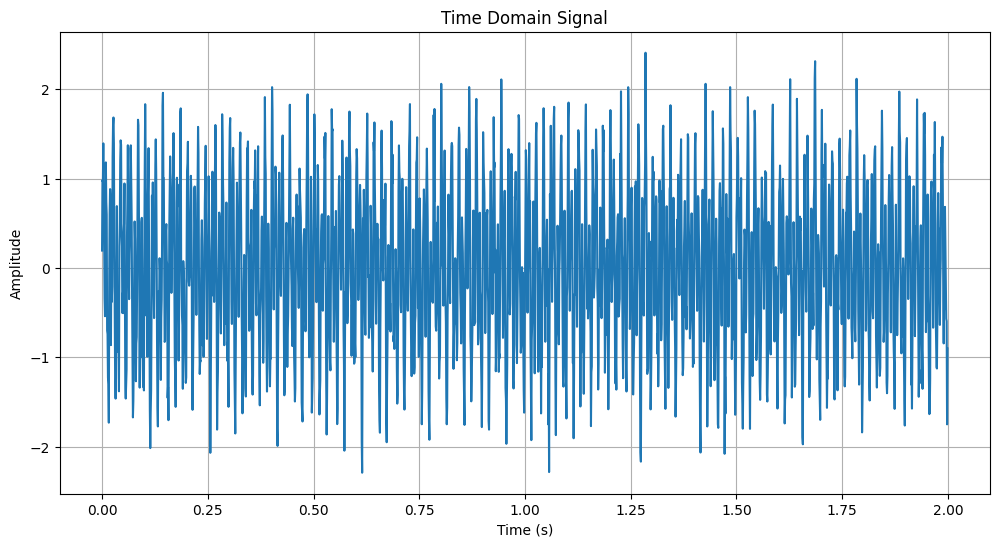

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

# 4. Plot the frequency-domain spectrum (both single-sided and full)

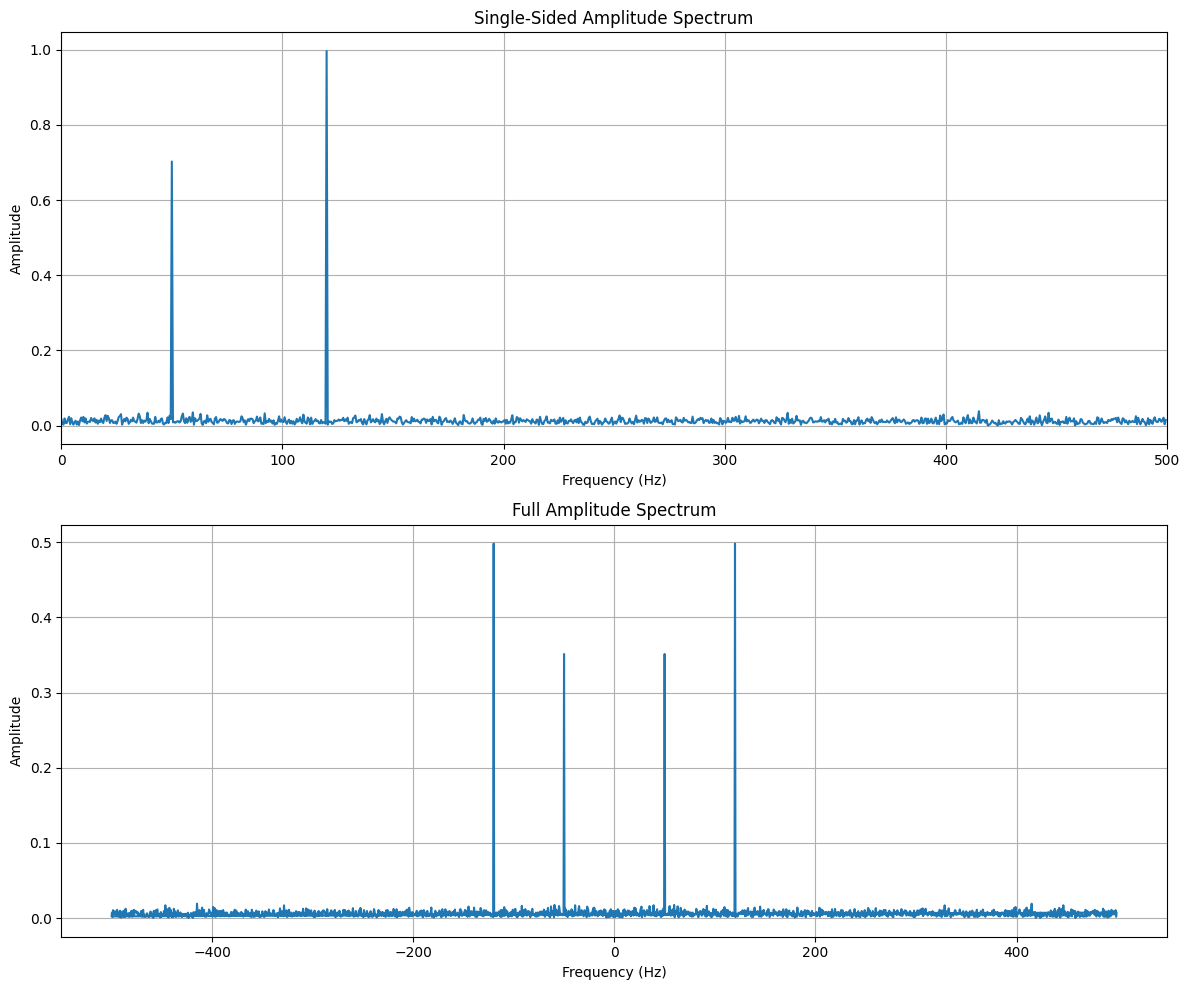

In [11]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, sampling_frequency / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()